# LSTM Time Series Forecasting — TSLA

---

Deep learning alternative to ARIMA (see `02_arima_tsla.ipynb`).

| Section | What we do |
|---------|------------|
| 1 | Load data & confirm stationarity (reuses cached raw data) |
| 2 | Scale prices and create sequences |
| 3 | Build and train the LSTM model |
| 4 | Forecast prices with confidence cone |
| 5 | Evaluate: MAE, RMSE, MAPE |
| 6 | Compare against ARIMA results |

### LSTM vs ARIMA — key difference in input

| | ARIMA | LSTM |
|--|-------|------|
| Input data | Daily returns (must be stationary) | Scaled prices (LSTM handles trends) |
| Why | ARIMA's math breaks on non-stationary series | LSTM's gating learns trends from price sequences |
| Output | Forecasted return -> compound to price | Forecasted price directly |
| Compounding needed? | Yes | No |

In [17]:
import sys, pathlib
cwd = pathlib.Path('.').resolve()
if (cwd / 'src').exists():
    sys.path.insert(0, str(cwd))
else:
    p = cwd
    while p.parent != p:
        p = p.parent
        if (p / 'src').exists():
            sys.path.insert(0, str(p))
            break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import src.data_loader

importlib.reload(src.lstm_utils)
from src.arima_utils import fetch_and_save, adf_report
from src.lstm_utils import (
    fit_scaler, create_sequences, build_test_sequences,
    build_lstm_model, train_model, forecast_with_confidence,
    evaluate_forecast, save_results
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

TICKER = 'TSLA'
START_DATE = '2015-01-01'
END_DATE = '2026-06-30'
TRAIN_END = '2024-12-31'
WINDOW_SIZE = 60
EPOCHS = 50
BATCH_SIZE = 32

print(f'Ticker      : {TICKER}')
print(f'Window size : {WINDOW_SIZE} days')
print(f'Epochs      : {EPOCHS} (EarlyStopping may stop sooner)')
print(f'Batch size  : {BATCH_SIZE}')

Ticker      : TSLA
Window size : 60 days
Epochs      : 50 (EarlyStopping may stop sooner)
Batch size  : 32


In [3]:
import os
os.remove('../data/raw/TSLA_raw.csv')

---
## Section 1 — Load Data & Stationarity Check

Reuses the cached raw file from the ARIMA notebook (`data/raw/TSLA_raw.csv`)
if present, otherwise downloads fresh. Same ADF finding as before — raw
prices are non-stationary. Here we handle that differently: instead of
differencing into returns, we scale prices to [0, 1] and let the LSTM's
gating mechanism learn the trend directly from the price sequence.

In [5]:
price = fetch_and_save(TICKER, START_DATE, END_DATE)
returns = price.pct_change().dropna()

print(f'Loaded {len(price)} trading days')
print(f'Date range : {price.index.min().date()} -> {price.index.max().date()}')

print('\nADF Test:')
adf_report(price, 'TSLA Price')
adf_report(returns, 'TSLA Returns')

print()
print('ARIMA approach: returns (stationary) -> forecast return -> compound to price')
print('LSTM approach : scaled prices [0,1] -> forecast next scaled price -> inverse-scale')
print('-> LSTM never needs the compounding step.')

[*********************100%***********************]  1 of 1 completed


  Saved raw data -> ../data/raw/TSLA_raw.csv  (2888 rows)
Loaded 2888 trading days
Date range : 2015-01-02 -> 2026-06-29

ADF Test:
  TSLA Price           ADF stat= -1.0696  p=0.727042  ->  NON-STATIONARY
  TSLA Returns         ADF stat=-53.9719  p=0.000000  ->  STATIONARY

ARIMA approach: returns (stationary) -> forecast return -> compound to price
LSTM approach : scaled prices [0,1] -> forecast next scaled price -> inverse-scale
-> LSTM never needs the compounding step.


---
## Section 2 — Prepare Data for LSTM

**Scaling rule**: fit the scaler ONLY on training data. Using the test
period's min/max would leak future information into preprocessing.

**Sequences**: the model needs to see a window of past days (not a single
day) to learn patterns, so we restructure the data into
`X[i] = last 60 scaled prices`, `y[i] = next scaled price`.

In [6]:
train_price = price.loc[:TRAIN_END]
test_price = price.loc[TRAIN_END:].iloc[1:]

print(f'Train : {len(train_price)} days  ({train_price.index[0].date()} -> {train_price.index[-1].date()})')
print(f'Test  : {len(test_price)} days  ({test_price.index[0].date()} -> {test_price.index[-1].date()})')

Train : 2516 days  (2015-01-02 -> 2024-12-31)
Test  : 372 days  (2025-01-02 -> 2026-06-29)


In [7]:
scaler, train_scaled = fit_scaler(train_price)
test_scaled = scaler.transform(test_price.values.reshape(-1, 1))

print(f'Training price range : ${train_price.min():.2f} -> ${train_price.max():.2f}')
print(f'After scaling        : {train_scaled.min():.4f} -> {train_scaled.max():.4f}')
print('Test prices are scaled using the TRAINING min/max (test values may exceed [0,1] — that is fine).')

Training price range : $9.58 -> $479.86
After scaling        : 0.0000 -> 1.0000
Test prices are scaled using the TRAINING min/max (test values may exceed [0,1] — that is fine).


In [8]:
X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test, y_test = build_test_sequences(train_scaled, test_scaled, WINDOW_SIZE)

X_train = X_train.reshape(-1, WINDOW_SIZE, 1)
X_test = X_test.reshape(-1, WINDOW_SIZE, 1)

print(f'X_train : {X_train.shape}   (samples x timesteps x features)')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'Note: X_test has {X_test.shape[0]} rows, matching the {len(test_price)} test days.')

X_train : (2456, 60, 1)   (samples x timesteps x features)
X_test  : (372, 60, 1)
y_train : (2456,)
Note: X_test has 372 rows, matching the 372 test days.


---
## Section 3 — Build & Train the LSTM Model

```
Input: (60, 1)      <- 60 days of scaled prices, 1 feature per day
     |
 LSTM(64 units)     <- learns price patterns across 60-day windows
     |
 Dropout(0.2)       <- regularization: prevents memorizing training data
     |
 Dense(1)           <- outputs tomorrow's scaled price
```

EarlyStopping monitors validation loss and restores the best epoch's
weights once it stops improving (patience=10).

In [9]:
model = build_lstm_model(WINDOW_SIZE, units=64, dropout=0.2)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                16896     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 16961 (66.25 KB)
Trainable params: 16961 (66.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
history = train_model(model, X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, patience=10)
print(f'\nTraining stopped at epoch {len(history.history["loss"])}/{EPOCHS}')

Epoch 1/50
70/70 [==============================] - 5s 37ms/step - loss: 0.0067 - val_loss: 0.0035
Epoch 2/50
70/70 [==============================] - 2s 26ms/step - loss: 0.0016 - val_loss: 0.0038
Epoch 3/50
70/70 [==============================] - 2s 30ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 4/50
70/70 [==============================] - 2s 34ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 5/50
70/70 [==============================] - 2s 32ms/step - loss: 0.0011 - val_loss: 0.0026
Epoch 6/50
70/70 [==============================] - 2s 33ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 7/50
70/70 [==============================] - 2s 32ms/step - loss: 9.6560e-04 - val_loss: 0.0016
Epoch 8/50
70/70 [==============================] - 2s 24ms/step - loss: 9.0391e-04 - val_loss: 0.0015
Epoch 9/50
70/70 [==============================] - 2s 26ms/step - loss: 9.0797e-04 - val_loss: 0.0015
Epoch 10/50
70/70 [==============================] - 2s 23ms/step - loss: 8.4160e-04 - val_loss: 

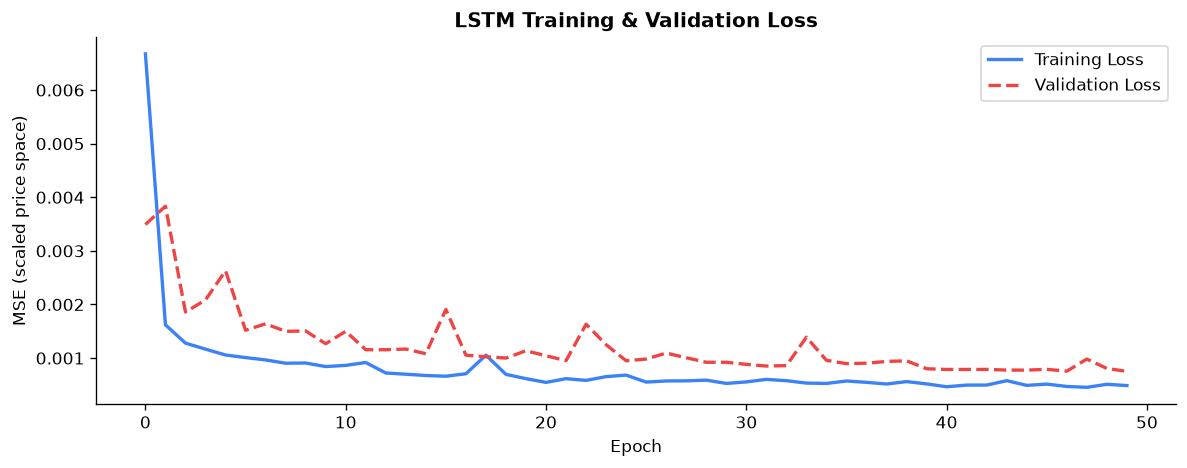

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], color='#3B82F6', lw=2, label='Training Loss')
ax.plot(history.history['val_loss'], color='#EF4444', lw=2, label='Validation Loss', linestyle='--')
ax.set_title('LSTM Training & Validation Loss', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (scaled price space)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 4 — Forecast Prices

LSTM predicts scaled prices directly (one-step-ahead: each prediction uses
the 60 actual observed days before it, not previous predictions). We
inverse-transform back to dollars, then apply the same sqrt(t) confidence
cone logic used in the ARIMA notebook, for a consistent comparison.

In [12]:
last_train_price = float(train_price.iloc[-1])
daily_std = float(returns.loc[:TRAIN_END].std())

fc_prices, fc_lower, fc_upper = forecast_with_confidence(
    model, X_test, scaler, last_train_price, daily_std
)
test_idx = test_price.index[:len(fc_prices)]
fc_series = pd.Series(fc_prices, index=test_idx)

print(f'Forecast range : ${fc_prices.min():.2f} -> ${fc_prices.max():.2f}')
print(f'Actual range   : ${test_price.min():.2f} -> ${test_price.max():.2f}')
print(f'Day-1 cone width   : +/-${1.96*daily_std*last_train_price*np.sqrt(1):.2f}')
print(f'Day-{len(fc_prices)} cone width : +/-${1.96*daily_std*last_train_price*np.sqrt(len(fc_prices)):.2f}')

Forecast range : $235.48 -> $478.36
Actual range   : $221.86 -> $489.88
Day-1 cone width   : +/-$28.50
Day-372 cone width : +/-$549.72


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

hist = train_price.iloc[-120:]
ax.plot(hist.index, hist.values, color='#94A3B8', lw=1.5, label='Training Price')
ax.plot(test_price.index, test_price.values, color='#3B82F6', lw=2.0, label='Actual Price (test)')
ax.plot(test_idx, fc_prices, color='#EF4444', lw=2.0, linestyle='--', label='LSTM Forecast')
ax.fill_between(test_idx, fc_lower, fc_upper, alpha=0.15, color='#EF4444', label='95% Confidence Cone')
ax.axvline(test_idx[0], color='gray', lw=1.5, linestyle=':', label='Forecast starts')

ax.set_title(f'{TICKER} — LSTM Forecast vs Actual', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:.0f}'))
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

---
## Section 5 — Evaluate Accuracy

In [13]:
actual_series = test_price.reindex(test_idx).dropna()
fc_aligned = fc_series.reindex(actual_series.index)

lstm_metrics = evaluate_forecast(actual_series, fc_aligned)

print('=' * 45)
print('  LSTM Forecast Metrics — TSLA')
print('=' * 45)
print(f"  MAE  : ${lstm_metrics['MAE']:.2f}")
print(f"  RMSE : ${lstm_metrics['RMSE']:.2f}")
print(f"  MAPE : {lstm_metrics['MAPE']:.2f}%")

  LSTM Forecast Metrics — TSLA
  MAE  : $11.13
  RMSE : $14.19
  MAPE : 3.15%


---
## Section 6 — Save Results & Compare Against ARIMA

Loads the ARIMA metrics saved by `02_arima_tsla.ipynb` and builds a direct
side-by-side comparison table for the Task 2 deliverable.

In [18]:
save_results(fc_series, fc_lower, fc_upper, lstm_metrics)

  Saved -> ../data/processed/tsla_lstm_forecast.csv  (372 rows)
  Saved -> ../data/processed/tsla_lstm_metrics.csv


'../data/processed/tsla_lstm_forecast.csv'

In [16]:
import os

arima_forecast_path = '../data/processed/tsla_arima_forecast_full.csv'

if os.path.exists(arima_forecast_path):
    arima_df = pd.read_csv(arima_forecast_path, parse_dates=['Date']).set_index('Date')
    arima_actual = arima_df['Actual_Price']
    arima_forecast = arima_df['Forecast_Price']

    from src.arima_utils import evaluate_forecast as eval_arima
    arima_metrics = eval_arima(arima_actual, arima_forecast)

    comparison = pd.DataFrame({
        'ARIMA(0,0,0)': arima_metrics,
        'LSTM': lstm_metrics,
    }).round(2)

    print('=== Model Comparison — TSLA Test Set ===')
    print(comparison)

    better = comparison.loc['MAPE'].idxmin()
    print(f'\nLower MAPE: {better}')
else:
    print('ARIMA forecast file not found — run 02_arima_tsla.ipynb first for comparison.')

=== Model Comparison — TSLA Test Set ===
      ARIMA(0,0,0)   LSTM
MAE         222.57  11.13
RMSE        245.05  14.19
MAPE         61.25   3.15

Lower MAPE: LSTM
